# Practical 7: Model Interpretation

This week we will focus on **model interpretation** for machine learning
models. We will use the California housing dataset from `sklearn`, train
an XGBoost model, evaluate training/testing performance, and apply
selected global and local explanation tools to explain this model.

## Learning Outcomes

-   Understand global interpretation methods: permutation importance and
    partial dependence plots (PDP).
-   Understand local and global explanation using SHAP.
-   Understand local explanation with LIME on selected instances.

# Starting the Practical

The process for this week is similar with previous weeks: download the
notebook to your `DSSS` folder (or wherever you keep your course
materials), switch over to `JupyterLab` (running in Podman/Docker), and
work through each section.

If you want to save the completed notebook to your Github repo, remember
to `add`, `commit`, and `push` your work.

> **Note**
>
> Suggestions for a Better Learning Experience:
>
> -   Keep software language set to English for easier debugging and
>     searching.
> -   Back up your work using cloud storage and/or Git.
> -   Avoid whitespace in filenames and dataset column names.

# Load data and train an XGBoost model

We will use the California housing dataset from `sklearn`. The target
variable is the median house value of block groups, so this is a
**regression** task.

This dataset consists of 20640 instances and 8 features, as follows:

| Feature    | Description                              |
|------------|------------------------------------------|
| MedInc     | Median income in block group             |
| HouseAge   | Median house age in block group          |
| AveRooms   | Average number of rooms per household    |
| AveBedrms  | Average number of bedrooms per household |
| Population | Block group population                   |
| AveOccup   | Average number of household members      |
| Latitude   | Block group latitude                     |
| Longitude  | Block group longitude                    |

In [1]:
# If needed, uncomment and run these lines once:
# %pip install xgboost shap lime

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from xgboost import XGBRegressor

In [2]:
# load California housing dataset
housing = fetch_california_housing(as_frame=True)
X = housing.data.copy()
y = housing.target.copy()

print("Feature names:", list(X.columns))
print("Data shape:", X.shape)

Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Data shape: (20640, 8)

In [3]:
# train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# train XGBoost regressor
xgb_model = XGBRegressor(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

# "accuracy" for regression is usually represented by R-squared
train_acc = xgb_model.score(X_train, y_train)
test_acc = xgb_model.score(X_test, y_test)

print(f"Train accuracy (R-squared): {train_acc:.3f}")
print(f"Test accuracy  (R-squared): {test_acc:.3f}")

# optional additional metrics
pred_test = xgb_model.predict(X_test)
print(f"Test MAE:  {mean_absolute_error(y_test, pred_test):.3f}")
print(f"Test RMSE: {mean_squared_error(y_test, pred_test):.3f}")

Train accuracy (R-squared): 0.900
Test accuracy  (R-squared): 0.838
Test MAE:  0.307
Test RMSE: 0.212

# Global interpretation #1: Permutation Importance

Permutation importance measures how much model performance drops after
randomly shuffling one feature at a time.

In [4]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    xgb_model,
    X_test,
    y_test,
    scoring='r2',
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std
}).sort_values('importance_mean', ascending=False)

print(perm_df.head(10))

      feature  importance_mean  importance_std
6    Latitude         1.133638        0.022544
7   Longitude         1.000647        0.014441
0      MedInc         0.400575        0.009796
5    AveOccup         0.147390        0.004267
2    AveRooms         0.067097        0.004132
1    HouseAge         0.041389        0.002588
4  Population         0.006165        0.000736
3   AveBedrms         0.005258        0.000787

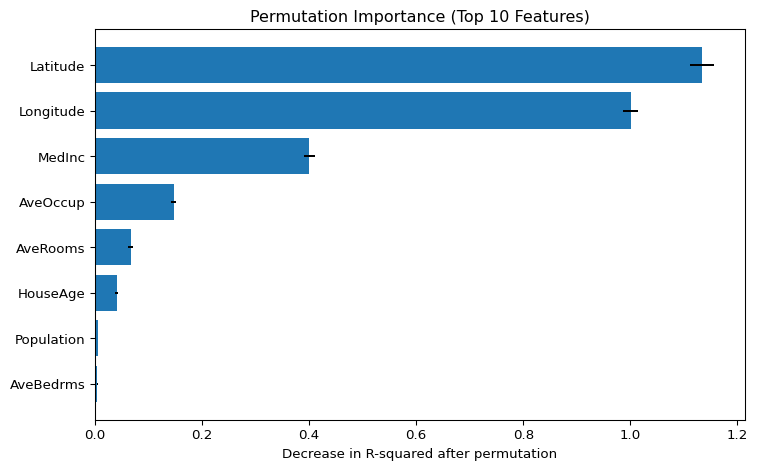

In [5]:
# plot permutation importance
fig, ax = plt.subplots(figsize=(8, 5))
plot_df = perm_df.head(10).iloc[::-1]
ax.barh(plot_df['feature'], plot_df['importance_mean'], xerr=plot_df['importance_std'])
ax.set_xlabel('Decrease in R-squared after permutation')
ax.set_title('Permutation Importance (Top 10 Features)')
plt.tight_layout()
plt.show()

# Global interpretation #2: Partial Dependence Plot (PDP)

PDP shows the marginal relationship between selected features and model
prediction.

Features used for PDP: ['Latitude', 'Longitude']

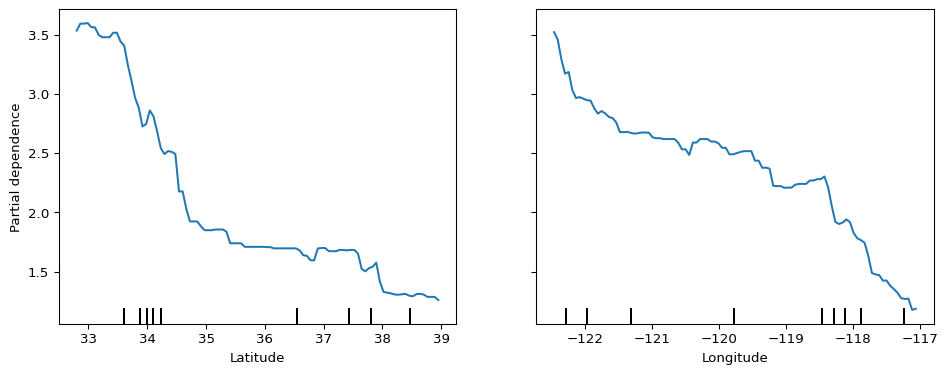

In [6]:
from sklearn.inspection import PartialDependenceDisplay

top_features = perm_df['feature'].head(2).tolist()
print("Features used for PDP:", top_features)

fig, ax = plt.subplots(figsize=(10, 4))
PartialDependenceDisplay.from_estimator(
    xgb_model,
    X_test,
    features=top_features,
    kind='average',
    ax=ax
)
plt.tight_layout()
plt.show()

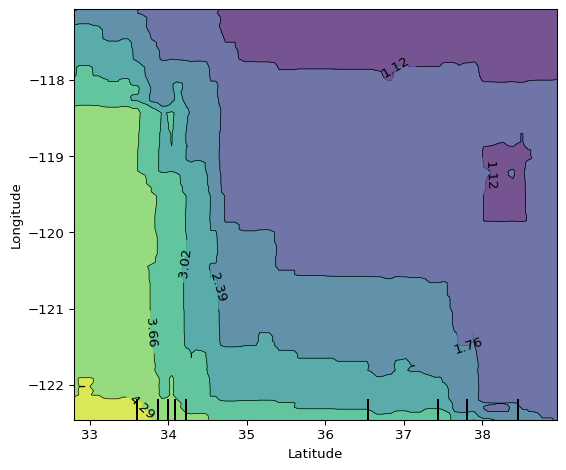

In [7]:
# 2D PDP interaction for the top 2 features
fig, ax = plt.subplots(figsize=(6, 5))
PartialDependenceDisplay.from_estimator(
    xgb_model,
    X_test,
    features=[(top_features[0], top_features[1])],
    kind='average',
    ax=ax
)
plt.tight_layout()
plt.show()

# LIME explanations on selected instances

LIME fits a local surrogate model around one observation to explain that
prediction.

In [8]:
from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    mode='regression',
    random_state=42
)

selected_instances = [0, 25]
print("Selected test indices for LIME:", selected_instances)

Selected test indices for LIME: [0, 25]

In [9]:
# explain first selected instance
idx = selected_instances[0]
exp0 = lime_explainer.explain_instance(
    data_row=X_test.iloc[idx].values,
    predict_fn=xgb_model.predict,
    num_features=8
)

print("LIME explanation (instance 0):")
for item in exp0.as_list():
    print(item)

LIME explanation (instance 0):
('34.26 < Latitude <= 37.72', -0.7837524926243604)
('MedInc <= 2.57', -0.5889227458599527)
('AveOccup > 3.28', -0.3902649272832985)
('-121.81 < Longitude <= -118.51', 0.32934340025813896)
('AveRooms <= 4.45', -0.2756012553522709)
('1.01 < AveBedrms <= 1.05', -0.057159699238348696)
('18.00 < HouseAge <= 29.00', -0.02105635946590629)
('1167.00 < Population <= 1726.00', -0.010292394052920647)

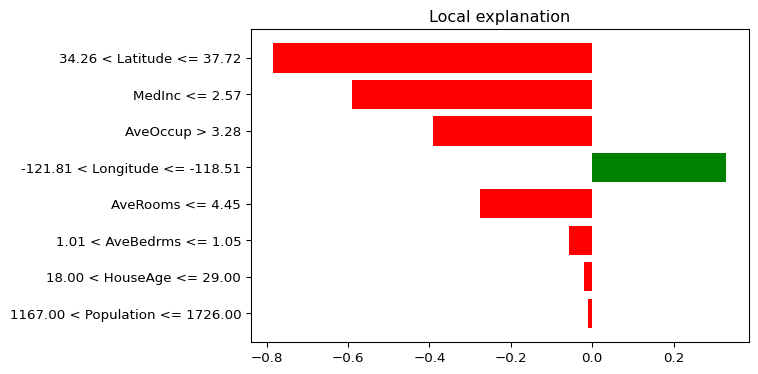

In [10]:
fig = exp0.as_pyplot_figure()
fig.set_size_inches(8, 4)
plt.tight_layout()
plt.show()

In [11]:
# explain second selected instance
idx = selected_instances[1]
exp1 = lime_explainer.explain_instance(
    data_row=X_test.iloc[idx].values,
    predict_fn=xgb_model.predict,
    num_features=8
)

print("LIME explanation (instance 25):")
for item in exp1.as_list():
    print(item)

LIME explanation (instance 25):
('34.26 < Latitude <= 37.72', -0.835702087663883)
('MedInc <= 2.57', -0.5262201177132679)
('-121.81 < Longitude <= -118.51', 0.38695363786225395)
('AveOccup > 3.28', -0.3473597244913454)
('AveRooms <= 4.45', -0.25683613674482764)
('1167.00 < Population <= 1726.00', 0.06943511133454196)
('1.01 < AveBedrms <= 1.05', 0.027832879625163558)
('HouseAge > 37.00', -0.007124887818044497)

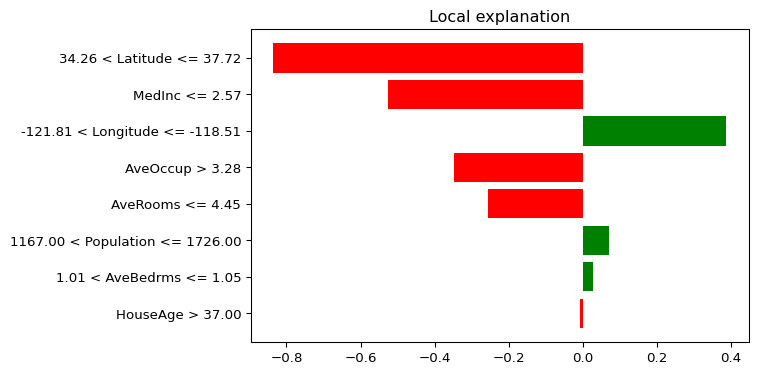

In [12]:
fig = exp1.as_pyplot_figure()
fig.set_size_inches(8, 4)
plt.tight_layout()
plt.show()

# SHAP explanations

SHAP explains predictions using additive feature attributions.

In [13]:
import shap

# for faster plotting, sample test data
X_test_sample = X_test.sample(n=min(500, len(X_test)), random_state=42)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_test_sample)

print("SHAP values shape:", shap_values.values.shape)

SHAP values shape: (500, 8)

## SHAP waterfall plot (single instance)

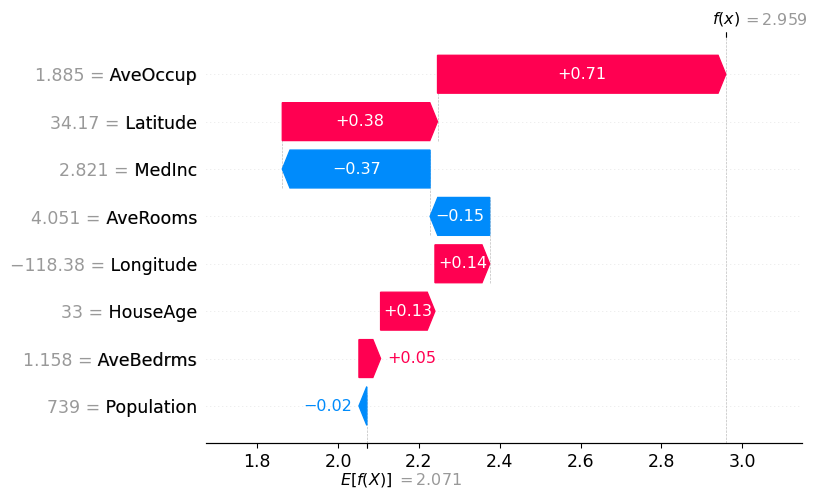

In [14]:
instance_idx = 0
shap.plots.waterfall(shap_values[instance_idx], max_display=12)

## SHAP force plot (single instance)

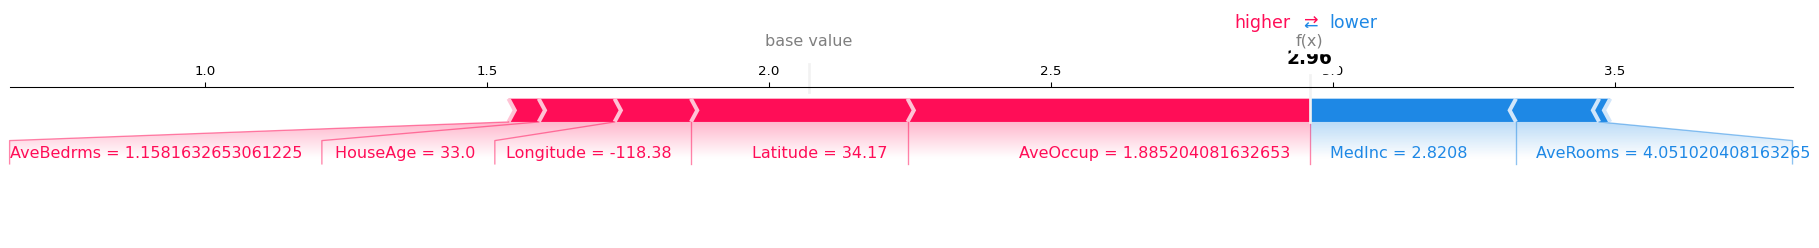

In [15]:
# static matplotlib force plot for compatibility in Quarto output
shap.force_plot(
    base_value=explainer.expected_value,
    shap_values=shap_values.values[instance_idx, :],
    features=X_test_sample.iloc[instance_idx, :],
    feature_names=X_test_sample.columns,
    matplotlib=True,
    show=False
)
plt.tight_layout()
plt.show()

## SHAP beeswarm plot

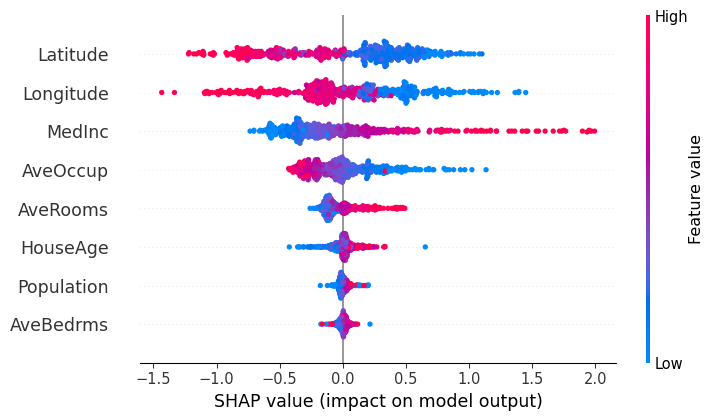

In [16]:
shap.plots.beeswarm(shap_values, max_display=15)

## SHAP feature importance plot (global)

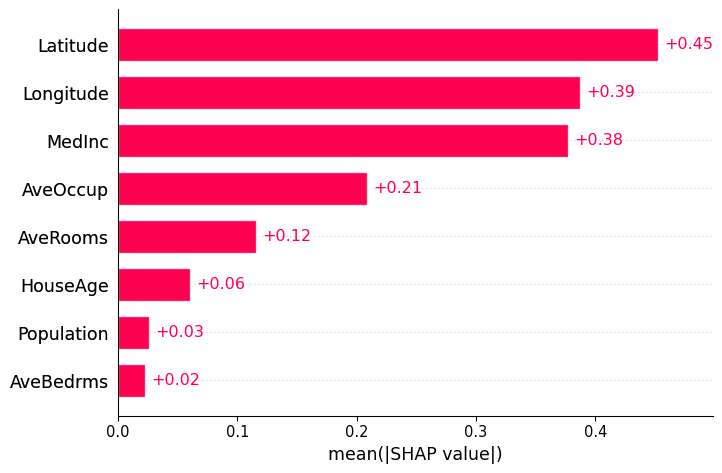

In [17]:
shap.plots.bar(shap_values, max_display=15)

## Comparing permutation importance and SHAP feature importance

Although these two methods sound similar, they are different in nature.
These two methods can give different feature rankings because they
measure different things: permutation importance measures the impact on
model performance, while SHAP measures the average contribution to
predictions.

So, how much do they agree with each other?

In [18]:
# create a combined dataframe for comparison
shap_importance_df = pd.DataFrame({
    'feature': X_test_sample.columns,
    'shap_importance': np.abs(shap_values.values).mean(axis=0)
}).sort_values('shap_importance', ascending=False)

comparison_df = perm_df.merge(shap_importance_df, on='feature', how='inner')
print(comparison_df)

      feature  importance_mean  importance_std  shap_importance
0    Latitude         1.133638        0.022544         0.452462
1   Longitude         1.000647        0.014441         0.386787
2      MedInc         0.400575        0.009796         0.377017
3    AveOccup         0.147390        0.004267         0.208232
4    AveRooms         0.067097        0.004132         0.115399
5    HouseAge         0.041389        0.002588         0.060043
6  Population         0.006165        0.000736         0.025706
7   AveBedrms         0.005258        0.000787         0.022653

# Summary

Congratulations! You have completed the practical on model
interpretation and feature importance. To summarise, we have practiced
with the following methods:

-   **Permutation importance** gives robust and model-agnostic global
    ranking by performance drop.
-   **PDP** shows average marginal effect of a feature (or feature
    pair).
-   **SHAP** provides both global and local additive attributions with
    consistent units.
-   **LIME** gives local and instance-specific surrogate explanations.

> **Note**
>
> Always remember that these methods explain the model, not the data.
> For a given task, the feature importance can differ across different
> models (e.g. random forest, XGBoost, neural network) and different
> explanation methods (e.g. permutation importance, SHAP feature
> importance).

# Exercises

1.  Try LIME on two extreme predictions (very high and very low) and
    compare explanations.
2.  Use PDP for other feature pairs and discuss possible non-linear
    relationships.
3.  Use these methods on your own dataset and interpret the results with
    caution.

# References and recommendations

1.  [scikit-learn: California housing
    dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html)
2.  [XGBoost documentation](https://xgboost.readthedocs.io/)
3.  [SHAP documentation](https://shap.readthedocs.io/)
4.  [LIME documentation](https://lime-ml.readthedocs.io/)